In [ ]:
# Data from Book Crossing - http://www2.informatik.uni-freiburg.de/~cziegler/BX/
! wget http://www2.informatik.uni-freiburg.de/~cziegler/BX/BX-CSV-Dump.zip

--2021-11-13 15:49:07--  http://www2.informatik.uni-freiburg.de/~cziegler/BX/BX-CSV-Dump.zip
Resolving www2.informatik.uni-freiburg.de (www2.informatik.uni-freiburg.de)... 132.230.105.133
Connecting to www2.informatik.uni-freiburg.de (www2.informatik.uni-freiburg.de)|132.230.105.133|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26085508 (25M) [application/zip]
Saving to: ‘BX-CSV-Dump.zip’

BX-CSV-Dump.zip     100%[===================>]  24.88M  11.4MB/s    in 2.2s    

2021-11-13 15:49:10 (11.4 MB/s) - ‘BX-CSV-Dump.zip’ saved [26085508/26085508]



In [ ]:
! unzip -q BX-CSV-Dump.zip

In [ ]:
# import library 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
user = pd.read_csv("BX-Users.csv", sep=";", encoding='latin-1')

In [ ]:
user.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
user.columns = ["UserID", "Location", "Age"]

In [ ]:
user.head()

,UserID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [ ]:
rating = pd.read_csv("BX-Book-Ratings.csv", sep=";", encoding='latin-1')
rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
rating.columns = ["UserID", "ISBN", "bookRating"]
rating.head()

,UserID,ISBN,bookRating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
rating.UserID.value_counts()

11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
          ...  
158698        1
17920         1
277135        1
275086        1
187812        1
Name: UserID, Length: 105283, dtype: int64

In [ ]:
rating.ISBN.value_counts()

0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
              ... 
0737011033       1
0590691937       1
2266136054       1
8880032674       1
0750516461       1
Name: ISBN, Length: 340556, dtype: int64

In [ ]:
df = pd.merge(user, rating, on ="UserID", how="inner")
df.head()

,UserID,Location,Age,ISBN,bookRating
0,2,"stockton, california, usa",18.0,0195153448,0
1,7,"washington, dc, usa",NaN,034542252,0
2,8,"timmins, ontario, canada",NaN,0002005018,5
3,8,"timmins, ontario, canada",NaN,0060973129,0
4,8,"timmins, ontario, canada",NaN,0374157065,0


In [ ]:
df.bookRating.max()

10

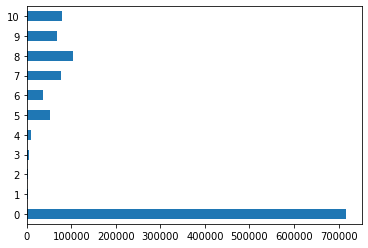

In [ ]:
df.bookRating.value_counts().sort_index().plot.barh()

In [ ]:
df = df.drop(columns=["Location", "Age"])
df.head()

,UserID,ISBN,bookRating
0,2,0195153448,0
1,7,034542252,0
2,8,0002005018,5
3,8,0060973129,0
4,8,0374157065,0


In [ ]:
df.UserID.nunique()

105283

In [ ]:
df.ISBN.nunique()

340556

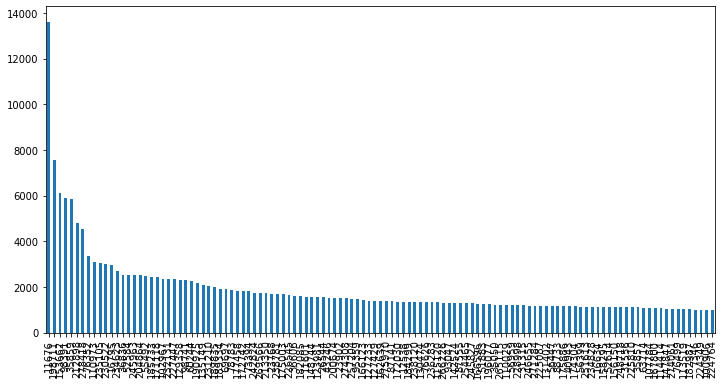

In [ ]:
plt.figure(figsize=(12, 6))
user_g = df.UserID.value_counts()[df.UserID.value_counts() > 1000]
user_g.plot.bar()

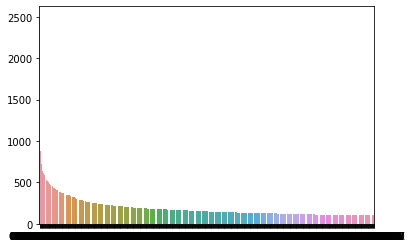

In [ ]:
rating_g = df.ISBN.value_counts()[df.ISBN.value_counts() > 100]
sns.barplot(x=rating_g.index, y=rating_g.values)

In [ ]:
df.groupby('ISBN')["bookRating"].mean().sort_values()

ISBN
0688009328     0.0
0517524589     0.0
1400049083     0.0
0517525038     0.0
0517525046     0.0
              ... 
0871352427    10.0
1573540706    10.0
8440684096    10.0
8440682697    10.0
0862418917    10.0
Name: bookRating, Length: 340556, dtype: float64

In [ ]:
np.mean([13, 14, 13, 12, 15, 13, 102])

26.0

In [ ]:
np.median([13, 14, 13, 12, 15, 13, 102])

13.0

In [ ]:
df.groupby('ISBN').agg({"bookRating":"mean", "UserID":"count"})

,bookRating,UserID
ISBN,,
0330299891,3.0,2
0375404120,1.5,2
0586045007,0.0,1
9022906116,3.5,2
9032803328,0.0,1
...,...,...
cn113107,0.0,1
ooo7156103,7.0,1
§423350229,0.0,1


In [ ]:
min_book_rating = 50 
filter_books = df["ISBN"].value_counts()[df.ISBN.value_counts() > min_book_rating].index.tolist()
# filter_books

In [ ]:
min_user_rating = 50 
filter_users = df["UserID"].value_counts()[df.UserID.value_counts() > min_user_rating].index.tolist()

In [ ]:
df.shape

(1149780, 3)

In [ ]:
df_new = df[(df.UserID.isin(filter_users)) 
          & (df.ISBN.isin(filter_books))]

In [ ]:
df_new.shape

(140516, 3)

In [ ]:
# Surprise - Python Lib for Recommendation 
! pip install surprise

     |████████████████████████████████| 11.8 MB 6.3 MB/s 
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.1-cp37-cp37m-linux_x86_64.whl size=1619432 sha256=d645cb80f63e3e2a013a9c73cf2ef0325c9cf9f34a0c67ad855d756cb871b469
  Stored in directory: /root/.cache/pip/wheels/76/44/74/b498c42be47b2406bd27994e16c5188e337c657025ab400c1c
Successfully built scikit-surprise


In [ ]:
# Data is in the form of 
# user ; item ; rating ; [timestamp]

# Rating - (0, 9)

In [ ]:
import surprise

In [ ]:
reader = surprise.Reader(rating_scale=(0,9))
data = surprise.Dataset.load_from_df(df_new[["UserID", "ISBN", "bookRating"]], reader=reader)

In [ ]:
data.df.head()

,UserID,ISBN,bookRating
394,243,0060915544,10
395,243,0060977493,7
397,243,0156006529,0
400,243,0316096199,0
401,243,0316601950,9


In [ ]:
algorithm = [surprise.NormalPredictor(), surprise.BaselineOnly(), 
        surprise.KNNBasic(), surprise.SVD(), surprise.CoClustering()]

In [ ]:
result = surprise.model_selection.cross_validate(surprise.NormalPredictor(), data, measures=["RMSE"], cv=3, verbose=False)

In [ ]:
result

{'fit_time': (0.1576859951019287, 0.2002863883972168, 0.20034384727478027),
 'test_rmse': array([4.6557277 , 4.6501138 , 4.66866185]),
 'test_time': (0.3897249698638916, 0.38278889656066895, 0.38686299324035645)}

In [ ]:
ltemp = []
for algo in algorithm:
  result = surprise.model_selection.cross_validate(algo, data, measures=["RMSE"], cv=3, verbose=False)
  

  tmp = pd.DataFrame.from_dict(result).mean(axis=0)
  # tmp = tmp.append(pd.Series([str(algo), index=["Algorithm"]]))
  ltemp.append(tmp)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


In [ ]:
df_new.isna().sum()

UserID        0
ISBN          0
bookRating    0
dtype: int64

In [ ]:
ltemp

[test_rmse    4.685247
 fit_time     0.195626
 test_time    0.555523
 dtype: float64, test_rmse    3.379059
 fit_time     0.527196
 test_time    0.277506
 dtype: float64, test_rmse    3.726612
 fit_time     0.798434
 test_time    5.871428
 dtype: float64, test_rmse    3.545379
 fit_time     5.597230
 test_time    0.412731
 dtype: float64, test_rmse    3.465889
 fit_time     2.911481
 test_time    0.498533
 dtype: float64]

In [ ]:
result_pd = pd.DataFrame(ltemp)

In [ ]:
result_pd["Algorithm"] = ["NormalPredictor", "BaselineOnly", 
        "KNNBasic", "SVD", "CoClustering"]

In [ ]:
result_pd

,test_rmse,fit_time,test_time,Algorithm
0,4.685247,0.195626,0.555523,NormalPredictor
1,3.379059,0.527196,0.277506,BaselineOnly
2,3.726612,0.798434,5.871428,KNNBasic
3,3.545379,5.597230,0.412731,SVD
4,3.465889,2.911481,0.498533,CoClustering


In [ ]:
surprise.model_selection.cross_validate(surprise.BaselineOnly(), data, measures=["RMSE"], cv=5, verbose=False)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...


{'fit_time': (0.5900771617889404,
  0.6242074966430664,
  0.6874105930328369,
  0.653435230255127,
  0.6682465076446533),
 'test_rmse': array([3.36449623, 3.36810419, 3.36037839, 3.34687681, 3.38498263]),
 'test_time': (0.18223285675048828,
  0.16181111335754395,
  0.17198705673217773,
  0.16898369789123535,
  0.1603531837463379)}

In [ ]:
trainset, testset = surprise.model_selection.train_test_split(data, test_size=0.20)

In [ ]:
algo = surprise.BaselineOnly()
algo.fit(trainset)

Estimating biases using als...


In [ ]:
prediction = algo.fit(trainset).test(testset)

Estimating biases using als...


In [ ]:
surprise.accuracy.rmse(prediction)

RMSE: 3.3714


3.371377359705798